# Project : Face Mask Detection using CNN

### 🛡️STEP 1 :- Business Problem:

- During and after the COVID-19 pandemic, organizations such as hospitals, airports, offices, and shopping malls needed an automated way to monitor whether people were wearing face masks. 
- Manually checking every person is time-consuming and prone to human error. The goal of this project was to build a computer vision model that can automatically classify whether a person is wearing a mask or not.

In [2]:
import numpy as np 
import pandas as pd 
import cv2
import os, sys
import pathlib
import glob
from keras import models
from keras.layers import Dense, Dropout, Input
from keras.models import Model, Sequential
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import keras.preprocessing.image as kpi
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import load_img, img_to_array, array_to_img
from keras.utils import to_categorical, plot_model
from PIL import Image

### Objective:

The objective of the project is to classify an input face image into one of two categories:

- With Mask
- Without Mask

This can later be integrated with CCTV cameras or webcam feeds for real-time monitoring

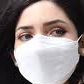

In [3]:
from IPython.display import display 
from IPython.display import Image as _Imgdis

def show(path):
    display(_Imgdis(filename=path, width=240, height=320))
    
show('D:\Image_Dataset\Face_Mask_Dataset\Train\WithMask\9.png')

### 📂STEP 2: Dataset

Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.


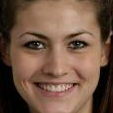

In [8]:
# create a data generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)

# load and iterate training dataset
train_it = train_datagen.flow_from_directory('D:\Image_Dataset\Face_Mask_Dataset\Train', 
                                       target_size = (150, 150), class_mode='binary', batch_size=32)
# load and iterate validation dataset
val_it = test_datagen.flow_from_directory('D:\Image_Dataset\Face_Mask_Dataset\Validation', 
                                     target_size = (150, 150),class_mode='binary', batch_size=32)
# load and iterate test dataset
test_it = test_datagen.flow_from_directory('D:\Image_Dataset\Face_Mask_Dataset\Test', 
                                      target_size = (150, 150), class_mode='binary', batch_size=32)

kpi.load_img(
    r'D:\Image_Dataset\Face_Mask_Dataset\Train\WithoutMask\316.png', color_mode="rgb", target_size=None, interpolation="nearest"
)

### 🧹STEP 3: Preprocessing & Augmentation

In [9]:
data = []
labels = []

path = "D:\Image_Dataset\Face_Mask_Dataset\Train"
for status in os.listdir(path):
    for image in glob.glob(path+"/"+status+"/"+"*.png"):
        img=load_img(image,target_size=(64,64))
        x = img_to_array(img)
        data.append(x)
        if status == "WithMask":
            labels.append(1)
        else:
            labels.append(0)


path2 = "D:\Image_Dataset\Face_Mask_Dataset\Test"
for status in os.listdir(path2):
    for image in glob.glob(path2+"/"+status+"/"+"*.png"):
        img=load_img(image,target_size=(64,64))
        x=img_to_array(img)
        data.append(x)
        if status == "WithMask":
            labels.append(1)
        else:
            labels.append(0)
 
#data includes 10000 train + 992 test images
            
X_val = []
y_val = []

path3 = "D:\Image_Dataset\Face_Mask_Dataset\Validation"
for status in os.listdir(path3):
    for image in glob.glob(path3+"/"+status+"/"+"*.png"):
        img=load_img(image,target_size=(64,64))
        x=img_to_array(img)
        X_val.append(x)
        if status == "WithMask":
            y_val.append(1)
        else:
            y_val.append(0)

In [10]:
data = np.array(data, dtype="float32")
labels = np.array(labels)

X_val= np.array(X_val, dtype="float32")
y_val = np.array(y_val)

labels = to_categorical(labels)
print (labels[4999])
print (labels[5000])
print (labels[9999])
print (labels[10000])

[0. 1.]
[1. 0.]
[1. 0.]
[0. 1.]


In [11]:
y_val = to_categorical(y_val)
print(y_val[0])

[0. 1.]


In [12]:
X_train, X_test = data[:10000], data[10001:]
y_train, y_test = labels[:10000], labels[10001:]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape)

print(X_train[0].shape)

(10000, 64, 64, 3) (10000, 2) (991, 64, 64, 3) (991, 2) (800, 64, 64, 3) (800, 2)
(64, 64, 3)


In [13]:
NUM_ROWS=64
NUM_COLS=64
NUM_CLASSES=2
BATCH_SIZE=32
EPOCHS=10

X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255
X_val = X_val.astype('float32')/255

### 🧠STEP 4: Model Building

In [14]:
from keras.layers import Conv2D, MaxPooling2D
#from keras.layers.normalization import BatchNormalization
from keras.layers import Flatten

model = Sequential([
    Conv2D(200,3, activation='relu', input_shape=(64,64,3)),
  
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    
    Dropout(0.5),
    
    Dense(50, activation='relu'),
    
    Dense(2,activation='softmax')  # activation change
])

#     Conv2D(100,3, activation='relu', input_shape=(64,64,3)),
#     MaxPooling2D(pool_size=(2, 2)),

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 🏋️ STEP 5: Training

In [15]:
model.compile(optimizer='adam',
             loss = 'categorical_crossentropy',
             metrics=['accuracy'])

model.fit(X_train, y_train,
            batch_size= BATCH_SIZE,
            epochs= EPOCHS,
            validation_data=(X_val, y_val),
            verbose=1)

         

score = model.evaluate(X_test, y_test, verbose=0)

print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 315ms/step - accuracy: 0.9486 - loss: 0.1660 - val_accuracy: 0.9912 - val_loss: 0.0346
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 322ms/step - accuracy: 0.9850 - loss: 0.0413 - val_accuracy: 0.9875 - val_loss: 0.0308
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 305ms/step - accuracy: 0.9895 - loss: 0.0293 - val_accuracy: 0.9388 - val_loss: 0.1856
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 305ms/step - accuracy: 0.9898 - loss: 0.0304 - val_accuracy: 0.9912 - val_loss: 0.0270
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 322ms/step - accuracy: 0.9904 - loss: 0.0284 - val_accuracy: 0.9912 - val_loss: 0.0307
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 314ms/step - accuracy: 0.9936 - loss: 0.0180 - val_accuracy: 0.9912 - val_loss: 0.0273
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 305ms/step - accuracy: 0.9947 - loss: 0.0148 - val_accuracy: 0.9900 - val_loss: 0.0484
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.9910 - loss

In [16]:
model.summary()
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)
# from IPython.display import SVG
# from keras.utils.vis_utils import model_to_dot
# SVG(model_to_dot(model).create(prog='dot', format='svg'))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 200)         │           5,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 200)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 192200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 192200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 50)                  │       9,610,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,847,258 (110.04 MB)

 Trainable params: 9,615,752 (36.68 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 19,231,506 (73.36 MB)

You must install pydot (`pip install pydot`) for `plot_model` to work.


### 📊 STEP 6: Evaluation

Mask


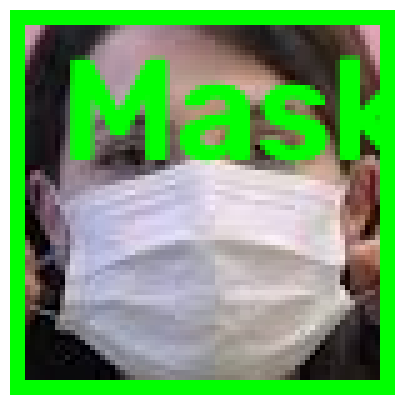

In [30]:
# Function to predict mask / no mask
def prediction(im):
    im = cv2.resize(im, (64, 64))
    im = im.astype("float32") / 255.0
    im = np.expand_dims(im, axis=0)

    result = model.predict(im, verbose=0)
    result = np.argmax(result, axis=1)[0]

    if result == 1:
        print("Mask")
    else:
        print("No Mask")

    return result

# Image path
ab = r'D:\Image_Dataset\Face_Mask_Dataset\Validation\WithMask\1374.png'

# Read image
img = cv2.imread(ab)

if img is None:
    print("Image not found!")
else:
    # Convert to RGB for display
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Predict
    pred = prediction(img)

    # Label and color
    if pred == 1:
        label = "Mask"
        color = (0, 255, 0)
    else:
        label = "No Mask"
        color = (255, 0, 0)

    # Draw border around the entire image
    h, w = img.shape[:2]
    cv2.rectangle(img, (0, 0), (w - 1, h - 1), color, 3)

    # Put prediction text
    cv2.putText(
        img,
        label,
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        color,
        2
    )

    # Display image
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
def reports (X_test,y_test):
    Y_pred = model.predict(X_test)
    y_pred = np.argmax(Y_pred, axis=1)
    target_names = ['Mask', 'No mask']

    
    classification = classification_report(np.argmax(y_test, axis=1), y_pred, target_names=target_names)
    confusion = confusion_matrix(np.argmax(y_test, axis=1), y_pred)
    score = model.evaluate(X_test, y_test, batch_size=32)
    Test_Loss =  score[0]*100
    Test_accuracy = score[1]*100
    
    return classification, confusion, Test_Loss, Test_accuracy

In [32]:
print('Test loss:', score[0])
print('Test accuracy:', score[1])
classification, confusion, Test_loss, Test_accuracy = reports(X_test,y_test)
classification = str(classification)
confusion = str(confusion)
print(format(classification))
print(format(confusion))

Test loss: 0.05832602456212044
Test accuracy: 0.9848637580871582
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9849 - loss: 0.0583
              precision    recall  f1-score   support

        Mask       0.98      0.99      0.99       509
     No mask       0.99      0.98      0.98       482

    accuracy                           0.98       991
   macro avg       0.99      0.98      0.98       991
weighted avg       0.98      0.98      0.98       991

[[504   5]
 [ 10 472]]


## Conclusion

In this project, a Convolutional Neural Network (CNN) was developed to automatically classify face images into two categories: **With Mask** and **Without Mask**. The model was trained and evaluated on a dedicated test dataset to assess its classification performance.

The CNN achieved a **test accuracy of 98.49%** with a **test loss of 0.0583** on **991 unseen test images**. The model correctly classified **976 images**, while only **15 images were misclassified**. It also achieved an F1-score of **99% for the Mask class** and **98% for the No Mask class**, demonstrating balanced performance across both categories.

Overall, the results show that the developed CNN model is highly effective for face-mask classification. The model can serve as a strong foundation for future deployment in **webcam or CCTV-based real-time monitoring systems**, particularly in environments such as hospitals, airports, offices, and other public spaces.